In [4]:
import awswrangler as wr
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# 1. Write the SQL query using your new Star Schema
sql = """
SELECT 
    p.product_category_name_english AS category,
    SUM(f.price) AS total_revenue
FROM fact_order_items f
JOIN dim_products p ON f.product_key = p.product_key
GROUP BY p.product_category_name_english
ORDER BY total_revenue DESC
LIMIT 5
"""

In [6]:
# 2. Execute the query on Athena and load into a Pandas DataFrame
print("Querying Athena... This might take a few seconds.")
df = wr.athena.read_sql_query(
    sql=sql, 
    database="olist_lakehouse_db",
    ctas_approach=False 
)

Querying Athena... This might take a few seconds.


/tmp/ipykernel_34878/2631556840.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='total_revenue', y='category', palette='mako')


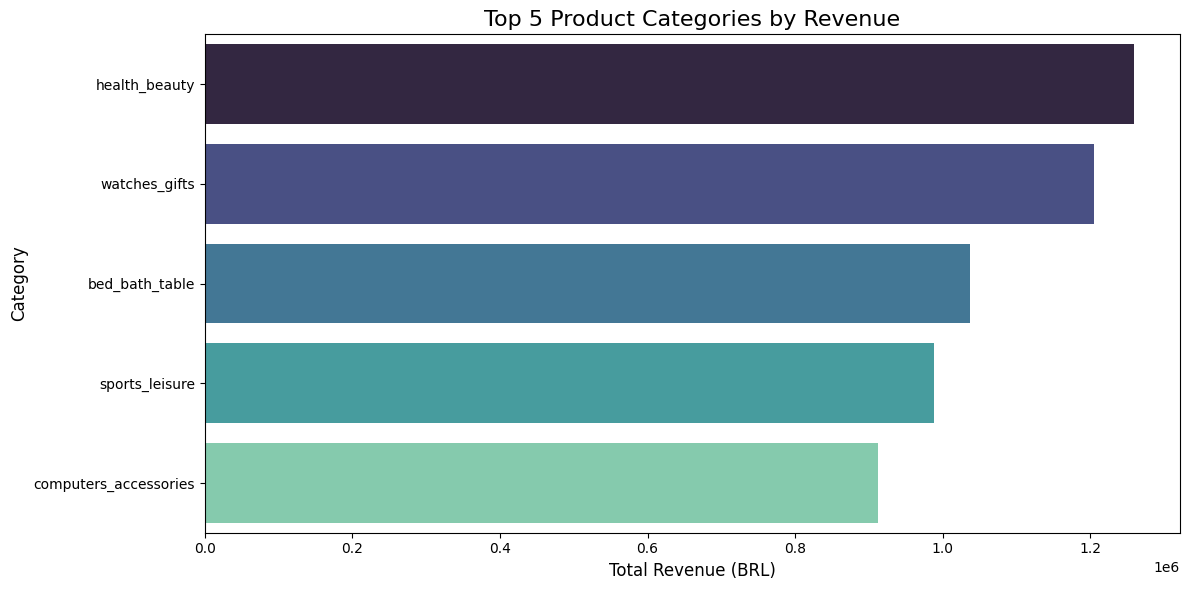

In [7]:
# 3. Build the Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='total_revenue', y='category', palette='mako')

plt.title('Top 5 Product Categories by Revenue', fontsize=16)
plt.xlabel('Total Revenue (BRL)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()

In [9]:
# Show the plot!
plt.show()